"Interactive Pipeline QA: We used this notebook linked via autoreload to our main modules to visually investigate specific subjects, determine our ICA exclusion criteria, and verify our difference-wave math before running the automated group pipeline."

In [1]:
%matplotlib qt

In [2]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
project_root = r"E:\masters Stuttgart\Uni Work\sem 3\EEG\finalCode\eeg_research"
if project_root not in sys.path: sys.path.insert(0, project_root)
import config
from project import preprocessing, ica, epochs, io

In [3]:
subject = "011"
raw = io.load_raw(subject)
# This interpolates the 6 channels and clears the bads list
raw_filt = preprocessing.preprocess_raw(raw, subject=subject)

Extracting EDF parameters from E:\masters Stuttgart\Uni Work\sem 3\EEG\dataset\ds004347\sub-011\eeg\sub-011_task-jacobsen_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from E:\masters Stuttgart\Uni Work\sem 3\EEG\dataset\ds004347\sub-011\eeg\sub-011_task-jacobsen_events.tsv.
Reading channel info from E:\masters Stuttgart\Uni Work\sem 3\EEG\dataset\ds004347\sub-011\eeg\sub-011_task-jacobsen_channels.tsv.
Reading electrode coords from E:\masters Stuttgart\Uni Work\sem 3\EEG\dataset\ds004347\sub-011\eeg\sub-011_task-jacobsen_electrodes.tsv.
Reading 0 ... 483839  =      0.000 ...   944.998 secs...


E:\masters Stuttgart\Uni Work\sem 3\EEG\finalCode\eeg_research\project\io.py:38: RuntimeWarning: The number of channels in the channels.tsv sidecar file (72) does not match the number of channels in the raw data file (73). Will not try to set channel names.
  raw = read_raw_bids(bids_path)
E:\masters Stuttgart\Uni Work\sem 3\EEG\finalCode\eeg_research\project\io.py:38: RuntimeWarning: Cannot set channel type for the following channels, as they are missing in the raw data: 'AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CPz', 'Cz', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FCz', 'FT7', 'FT8', 'Fp1', 'Fp2', 'Fpz', 'Fz', 'Iz', 'O1', 'O2', 'Oz', 'P1', 'P10', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'PO3', 'PO4', 'PO7', 'PO8', 'POz', 'Pz', 'T7', 'T8', 'TP7', 'TP8'
  raw = read_raw_bids(bids_path)
E:\masters 

Applied standard BioSemi64 montage.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 3381 samples (6.604 s)

Resampling data from 512.0 Hz to 256 Hz...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


In [4]:
# 1. Fit the ICA
ica_obj = ica.fit_ica(raw_filt, subject=subject)

# 2. Apply the ICA using our ICA_EXCLUDE_MAP from config.py
# This is what removes the blinks and prevents the 82 drops
raw_clean = ica.apply_ica(raw_filt, ica_obj, subject=subject)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 17.3s.
Overwriting existing file.
Writing ICA solution to E:\masters Stuttgart\Uni Work\sem 3\EEG\dataset\ds004347\derivatives\eegtigers\sub-011\sub-011_ica.fif...
Overwriting existing file.
Saved ICA for sub-011 to E:\masters Stuttgart\Uni Work\sem 3\EEG\dataset\ds004347\derivatives\eegtigers\sub-011\sub-011_ica.fif
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components


In [28]:
ica_obj.plot_components(picks=range(30));

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
472 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
472 matching events found
No baseline correction applied
0 projection items activated


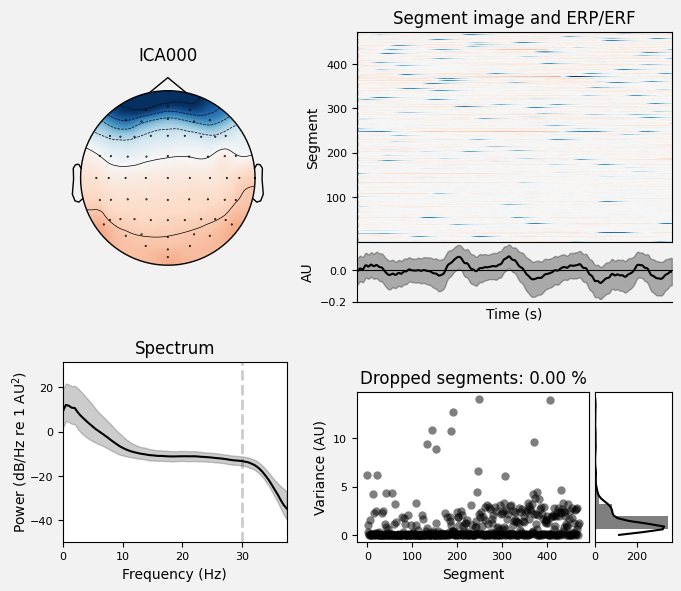

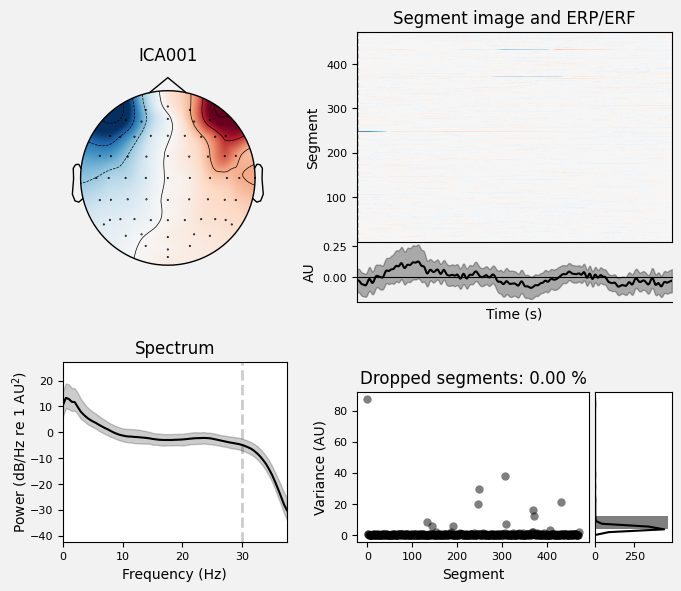

Creating RawArray with float64 data, n_channels=2, n_times=483840
    Range : 0 ... 483839 =      0.000 ...   944.998 secs
Ready.
Using matplotlib as 2D backend.


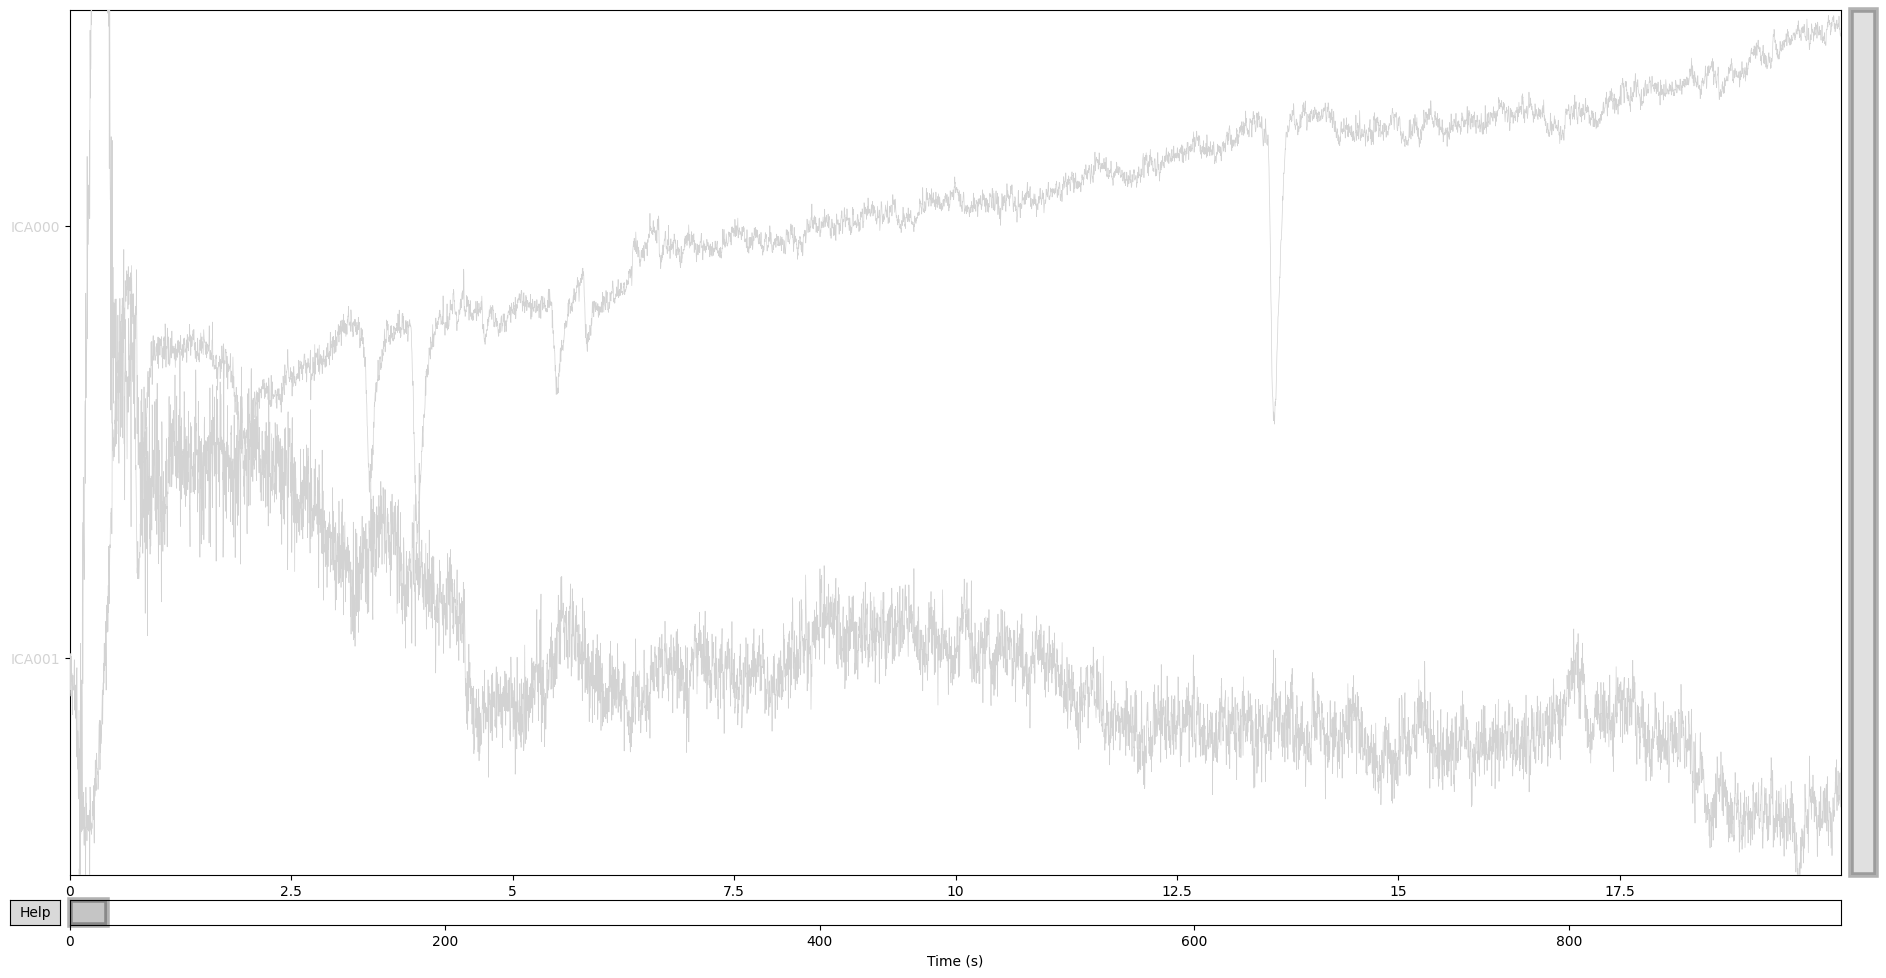

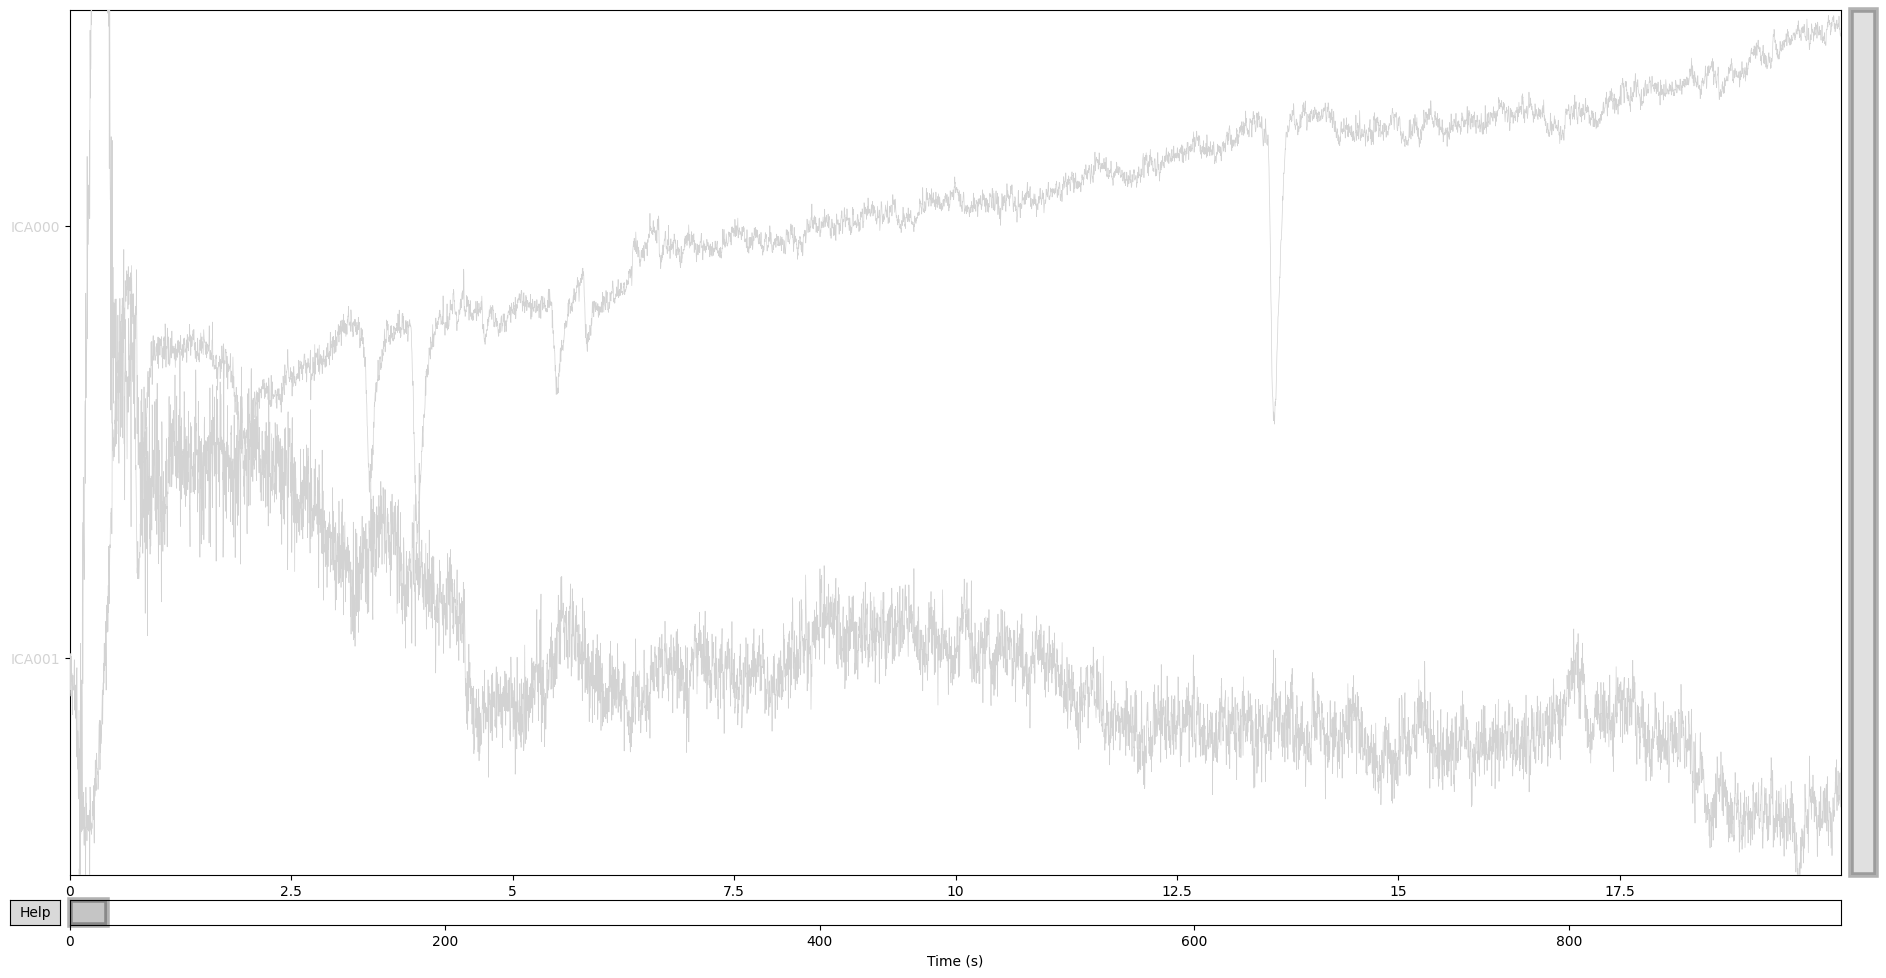

In [5]:
# Assuming 'raw_filt' and 'ica' are already loaded in our notebook:
components_to_check = [0,1] # Pass a list of IDs (0-indexed as per ICA) we are suspicious of and it generated power spectrum
ica_obj.plot_properties(raw_filt, picks=components_to_check)
ica_obj.plot_sources(raw, picks=components_to_check)

# Mark the exclusions in config.py and then re-run from cell 3 to get the updated results.

In [5]:
# Now we epoch the CLEAN data (this should result in less drops)
epochs_obj = epochs.make_epochs(raw_clean, subject=subject)

print(f"Final Trials: {len(epochs_obj)}")
# Now we can check properties without the blinks interfering
# ica_obj.plot_properties(epochs_obj, picks=[0, 1, 2])

Not setting metadata
160 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 160 events and 513 original time points ...
    Rejecting  epoch based on EEG : ['P9']
    Rejecting  epoch based on EEG : ['CP2']
    Rejecting  epoch based on EEG : ['POz']
    Rejecting  epoch based on EEG : ['Fz']
4 bad epochs dropped
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved epochs for sub-011 to E:\masters Stuttgart\Uni Work\sem 3\EEG\dataset\ds004347\derivatives\eegtigers\sub-011\sub-011_epo.fif
Final Trials: 156


In [7]:
# --- SPN VALIDATION CELL ---

# 1. Get the average ERP for each condition
evoked_sym = epochs_obj["symmetry"].average()
evoked_ran = epochs_obj["random"].average()

# 2. Pick the specific SPN channels defined in our config (PO7, PO8, etc.)
# We multiply by 1e6 because MNE stores data in Volts, but we want microVolts (µV)
sym_uv = evoked_sym.copy().pick(config.ERP_CHANNELS).data.mean() * 1e6
ran_uv = evoked_ran.copy().pick(config.ERP_CHANNELS).data.mean() * 1e6

print(f"--- Channel Group: {config.ERP_CHANNELS} ---")
print(f"Symmetry Mean: {sym_uv:.4f} µV")
print(f"Random Mean:   {ran_uv:.4f} µV")
print(f"Net SPN:       {sym_uv - ran_uv:.4f} µV")

# Visual sanity check: If these two values are identical to the 10th decimal, 
# Our event codes might not be splitting the data correctly.

--- Channel Group: ['PO7', 'PO8', 'Oz', 'O1', 'O2', 'POz'] ---
Symmetry Mean: -0.1471 µV
Random Mean:   0.4014 µV
Net SPN:       -0.5485 µV


# We want three before-vs-after checks:

# Frontal channels: did blink/frontal contamination reduce?

# Posterior channels: did the visual/SPN signal stay intact?

# Difference wave: did symmetry-minus-random keep the same overall shape?

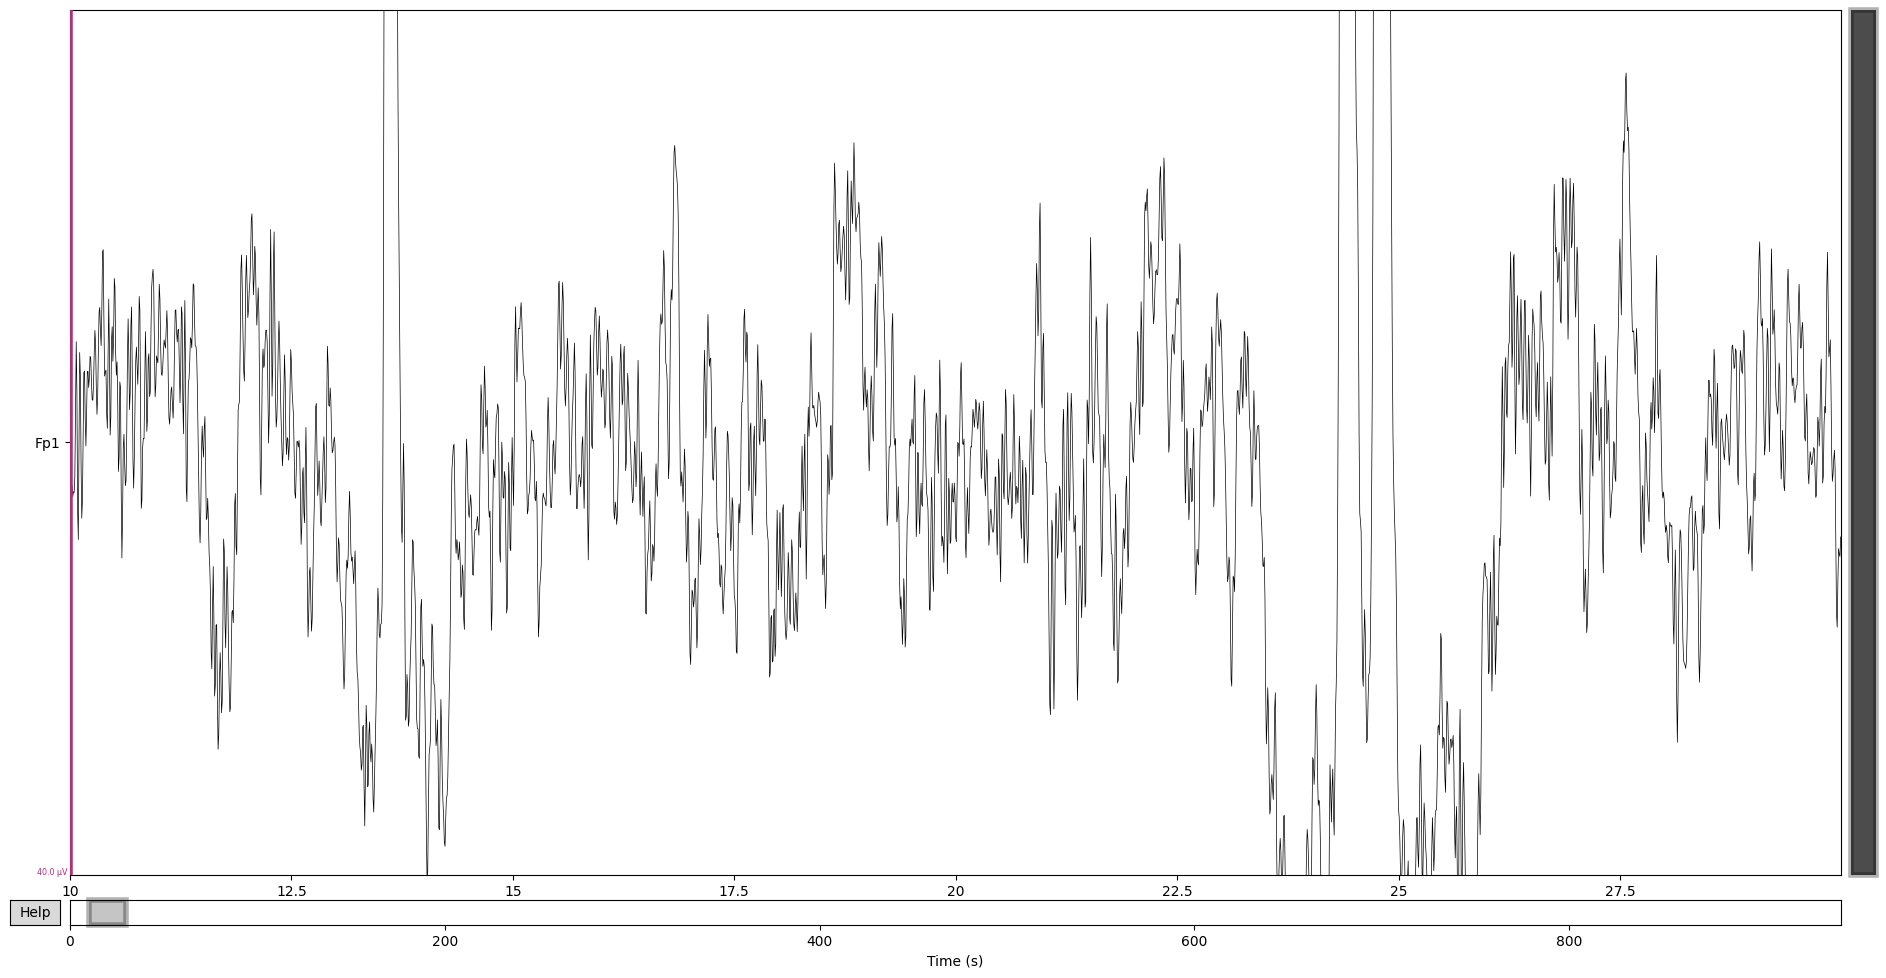

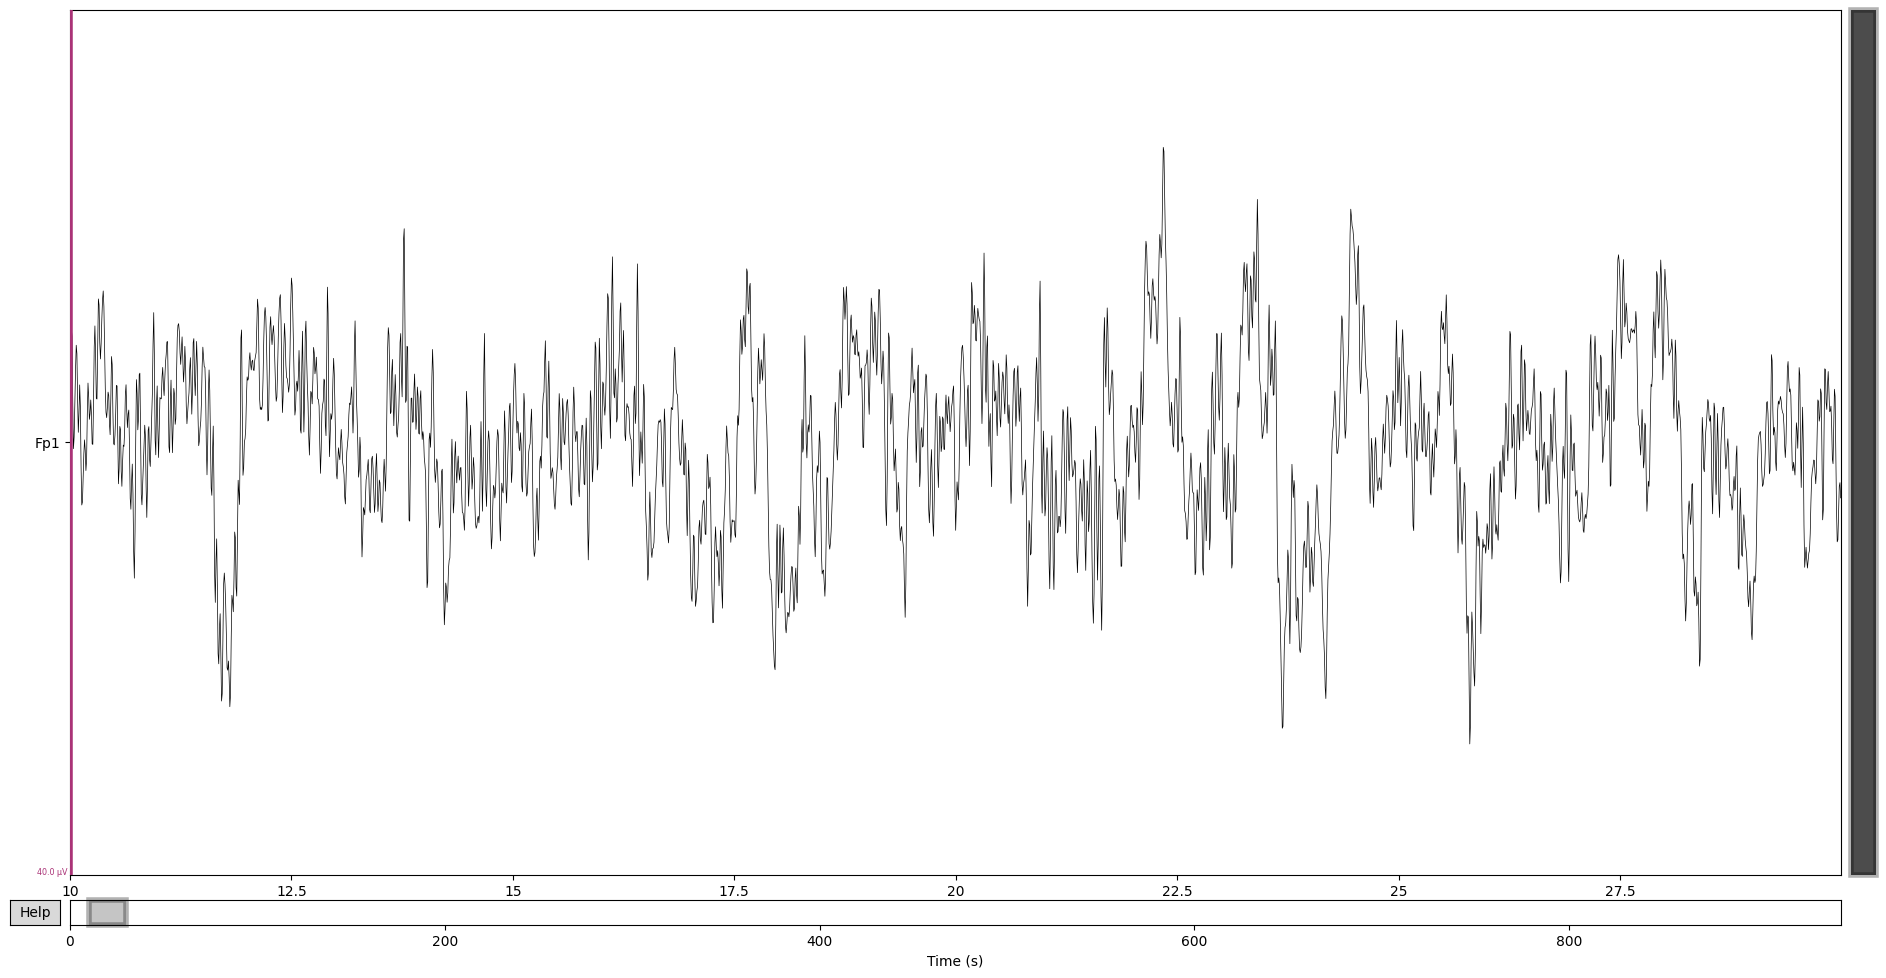

In [9]:
# --- CHECK 1: FRONTAL CLEANUP ---
frontal_ch = "Fp1" 

if frontal_ch in raw_filt.ch_names:
    idx = raw_filt.ch_names.index(frontal_ch)
    # Compare original filtered vs ICA cleaned
    raw_filt.plot(order=[idx], start=10, duration=20, title="Before ICA", show=True)
    raw_clean.plot(order=[idx], start=10, duration=20, title="After ICA", show=True)

No projector specified for this dataset. Please consider the method self.add_proj.


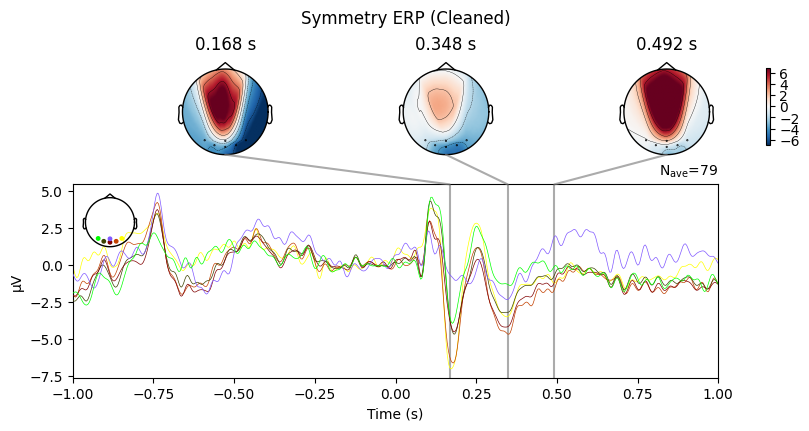

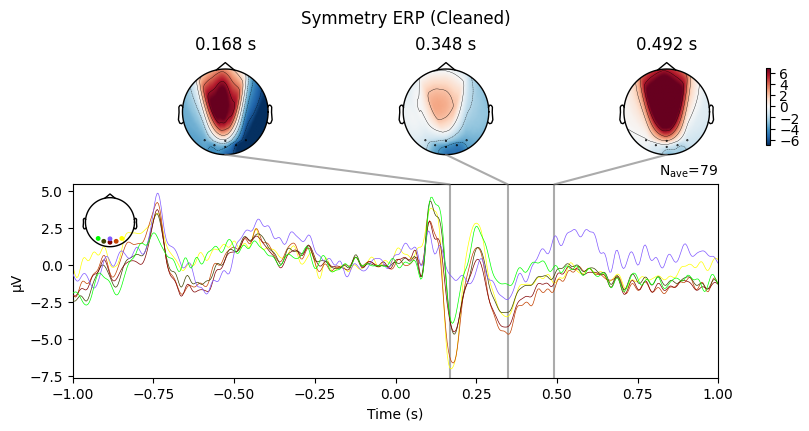

In [12]:
# --- CHECK 2: POSTERIOR INTEGRITY ---
# ERP_CHANNELS is from our config: ["PO7", "PO8", "Oz", "O1", "O2", "POz"]
evoked_sym = epochs_obj["symmetry"].average()
evoked_ran = epochs_obj["random"].average()

# Verify that the brain's visual response is still there
evoked_sym.plot_joint(picks=config.ERP_CHANNELS, title="Symmetry ERP (Cleaned)")

In [13]:
# 1. Calculate the difference (Symmetry - Random)
spn_diff = mne.combine_evoked([evoked_sym, evoked_ran], weights=[1, -1])

# 2. Narrow down to our ROI channels
spn_roi = spn_diff.copy().pick(config.ERP_CHANNELS)

# 3. Calculate the Final Value for our report (300ms to 1000ms)
final_spn_value = spn_roi.copy().crop(0.3, 1.0).data.mean() * 1e6

# 4. Plot the result
print(f"Verified SPN for Sub-001: {final_spn_value:.4f} µV")
spn_roi.plot(titles=f"Sub-001 SPN Difference (Value: {final_spn_value:.2f} µV)")

NameError: name 'mne' is not defined